In [2]:
# Python Trading Strategy Backtest: Moving Average Crossover on AAPL


# This project uses Python to download real AAPL stock data, calculate short-term and long-term moving averages, generate buy and sell signals, and compare the strategy's performance against a simple buy-and-hold approach.

In [3]:
import yfinance as yf
import matplotlib.pyplot as plt

In [4]:
data = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

prices = data["Close"].squeeze().tolist()

[*********************100%***********************]  1 of 1 completed


In [5]:
data = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

prices = data["Close"].squeeze().tolist()

[*********************100%***********************]  1 of 1 completed


In [7]:
short_window = 5
long_window = 10

In [8]:
signals = []
positions = []
daily_returns = []
strategy_returns = []

position = 0

for i in range(len(prices)):

    # daily return
    if i == 0:
        day_return = 0
    else:
        day_return = (prices[i] - prices[i-1]) / prices[i-1]
    daily_returns.append(day_return)

    # not enough data yet
    if i < long_window - 1:
        signals.append("No signal")
        positions.append(position)
        strategy_returns.append(0)
    else:
        short_ma = sum(prices[i-short_window+1:i+1]) / short_window
        long_ma = sum(prices[i-long_window+1:i+1]) / long_window

        if short_ma > long_ma:
            signal = "Buy"
            position = 1
        else:
            signal = "Sell"
            position = 0

        signals.append(signal)
        positions.append(position)

        strat_return = positions[i-1] * day_return
        strategy_returns.append(strat_return)

In [9]:
strategy_equity = []
buy_hold_equity = []

strategy_value = 1
buy_hold_value = 1

for i in range(len(prices)):
    strategy_value *= (1 + strategy_returns[i])
    buy_hold_value *= (1 + daily_returns[i])

    strategy_equity.append(strategy_value)
    buy_hold_equity.append(buy_hold_value)

In [10]:
strategy_total_return = strategy_equity[-1] - 1
buy_hold_return = buy_hold_equity[-1] - 1

print("Strategy Return:", round(strategy_total_return, 4))
print("Buy & Hold Return:", round(buy_hold_return, 4))

Strategy Return: 0.185
Buy & Hold Return: 0.548


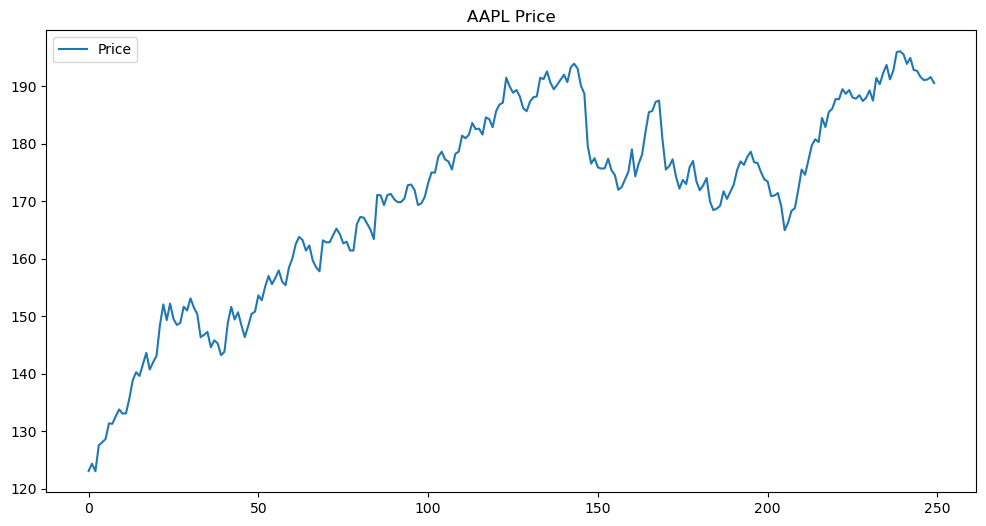

In [11]:
plt.figure(figsize=(12,6))
plt.plot(prices, label="Price")
plt.title("AAPL Price")
plt.legend()
plt.show()

In [12]:
## Conclusion

# The moving average crossover strategy was able to identify trends and reduce some downside risk. However, during this period, the strategy underperformed a simple buy-and-hold approach.

# This demonstrates that while trend-following strategies can be useful, their performance depends heavily on market conditions.